# Введение

**Цель проекта:**

Создать точную и надежную модель машинного обучения для диагностики сердечно-сосудистых заболеваний (ССЗ) на основе медицинских данных пациентов.

**Задачи:**

- Провести разведочный анализ данных (EDA).
- Очистить и подготовить данные: удалить выбросы, заполнить пропуски, закодировать категориальные признаки.
- Построить и сравнить три разнородные модели: логистическую регрессию, случайный лес и нейронную сеть.
- Оптимизировать гиперпараметры лучших моделей.
- Оценить качество моделей по ключевым метрикам: ROC-AUC, Precision, Recall, Accuracy.

**Методы и инструменты:**

- Язык: Python.
- Библиотеки: pandas, numpy, scikit-learn, TensorFlow/Keras, XGBoost, Optuna, matplotlib, seaborn.
- Валидация: кросс-валидация (5 фолдов) + тестовая выборка.
- Метрики: ROC-AUC, Precision, Recall, Accuracy.

# Описание датасета

- **Age** (возраст);
- **Sex** (пол);
- **Resting_blood_pressure** (артериальное давление в состоянии покоя);
- **Serum_cholestoral** (уровень холестерина в крови mg/dl);
- **Fasting_blood_sugar** (анализ глюкозы в крови натощак (> 120 mg/dl));
- **Maximum_heart_rate_achieved** (максимальная частота сердечных сокращений);
- **Exercise_induced_angina** (стенокардия при нагрузке),
Oldpeak (депрессия ST-сегмента);
- **Slope** (наклон пикового сегмента ST при физической нагрузке);
- **Number_of_major_vessels** (количество крупных сосудов (0-3), окрашенных с помощью флюороскопии);
- **Resting_electrocardiographic_results** (результаты электрокардиографических исследований в покое 0, 1, 2);
- **Thal** (3 = норма; 6 = фиксированный дефект; 7 = обратимый дефект);
- **Chest_bin** (боль в груди от 1 до 4).




# Импорт библиотек

In [3]:
!pip install optuna


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
pip install tensorflow


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_score,
    KFold
)
import category_encoders as ce

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression

import optuna

from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    multilabel_confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    auc,
    make_scorer
)

import scipy.optimize as opt
import scipy.stats as stats
from scipy.stats import randint              
from scipy.stats import (           
    uniform,                        
    norm                                   
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.inspection import permutation_importance

import pylab as pl

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session
from tensorflow.keras.metrics import Precision, Recall, AUC

import joblib 
import gdown


In [6]:
# Уберем предупреждения, чтобы они не загромождали вывод
import warnings
warnings.filterwarnings('ignore')

# Импорт данных

In [ ]:
url = "https://drive.google.com/file/d/17ZS3DivGjAILgeyd_5v7jAFxNpouQjb9/view?usp=drive_link"
gdown.download(url, "heart_train.csv", quiet=False, fuzzy=True)
ha_df = pd.read_csv("heart_train.csv")
ha_df.head()

Downloading...
From: https://drive.google.com/uc?id=17ZS3DivGjAILgeyd_5v7jAFxNpouQjb9
To: /Users/Administrator/Desktop/IDE/Нейронные сети/Глубокое обучение и нейронные сети. Итоговый проект/heart_train.csv
100%|██████████| 53.8M/53.8M [05:10<00:00, 173kB/s] 


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


# Разведочный анализ данных (EDA)

## Общая информация

In [8]:
# Размер датасета
ha_df.shape

(600000, 15)

In [9]:
# Выводим информацию о датасете
ha_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  

Датафрейм состоит из 600000 строк и 15 колонок (столбцов). Содержит 14 признаков-предикторов и 1 целевой ('class').
Типы данных, представленные в датафрейме - float64 и int64 (числовые).
В датасете есть как числовые, так и категориальные признаки. Посмотрим на них более внимательно.  

## Работа с пропусками

In [10]:
# Посчитаем пропуски в данных
ha_df.isnull().sum()

ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64

Пропусков в данных нет

## Числовые признаки

### Описательная статистика

In [11]:
ha_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,600000.0,299999.500000,173205.225094,0.000000,149999.750000,299999.500000,449999.250000,599999.000000
age,600000.0,54.426085,9.086041,26.061695,48.078493,55.133425,60.663775,79.591647
sex,600000.0,0.677447,0.467454,0.000000,0.000000,1.000000,1.000000,1.000000
chest,600000.0,3.170247,0.949618,-0.538498,3.000000,3.000000,4.000000,4.000000
resting_blood_pressure,600000.0,131.340485,17.842450,82.918527,119.924094,129.727941,139.915216,209.673650
serum_cholestoral,600000.0,249.592420,51.699976,98.326263,216.475964,244.233699,274.345453,527.755764
fasting_blood_sugar,600000.0,0.150757,0.357812,0.000000,0.000000,0.000000,0.000000,1.000000
resting_electrocardiographic_results,600000.0,1.020148,0.994204,0.000000,0.000000,2.000000,2.000000,2.000000
maximum_heart_rate_achieved,600000.0,149.592069,23.072593,61.844168,135.704237,153.224828,165.165497,208.735196
exercise_induced_angina,600000.0,0.333502,0.471464,0.000000,0.000000,0.000000,1.000000,1.000000


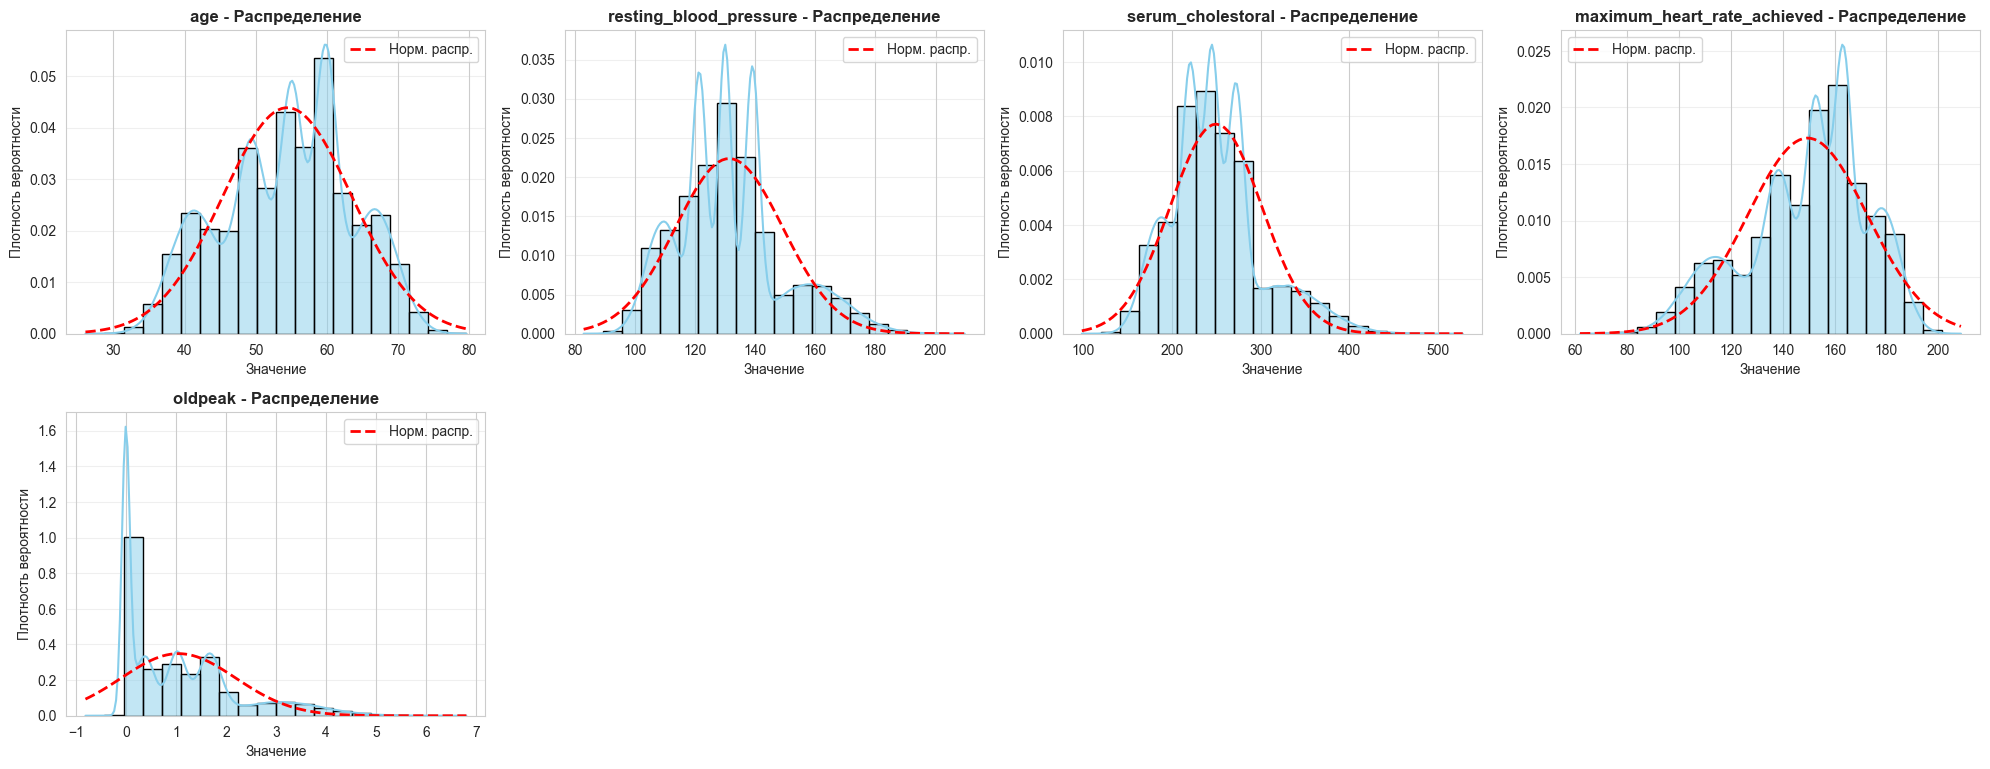

In [12]:
numeric_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'maximum_heart_rate_achieved', 'oldpeak']

sns.set_style("whitegrid")
plt.figure(figsize=(20, 15))

# Построение гистограмм
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(ha_df[col], bins=20, kde=True, color='skyblue', edgecolor='black', stat='density')
    mu, sigma = ha_df[col].mean(), ha_df[col].std()
    x = np.linspace(ha_df[col].min(), ha_df[col].max(), 100)
    y = norm.pdf(x, mu, sigma)

    plt.plot(x, y, 'r--', linewidth=2, label='Норм. распр.')

    plt.title(f'{col} - Распределение', fontsize=12, fontweight='bold')
    plt.xlabel('Значение')
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

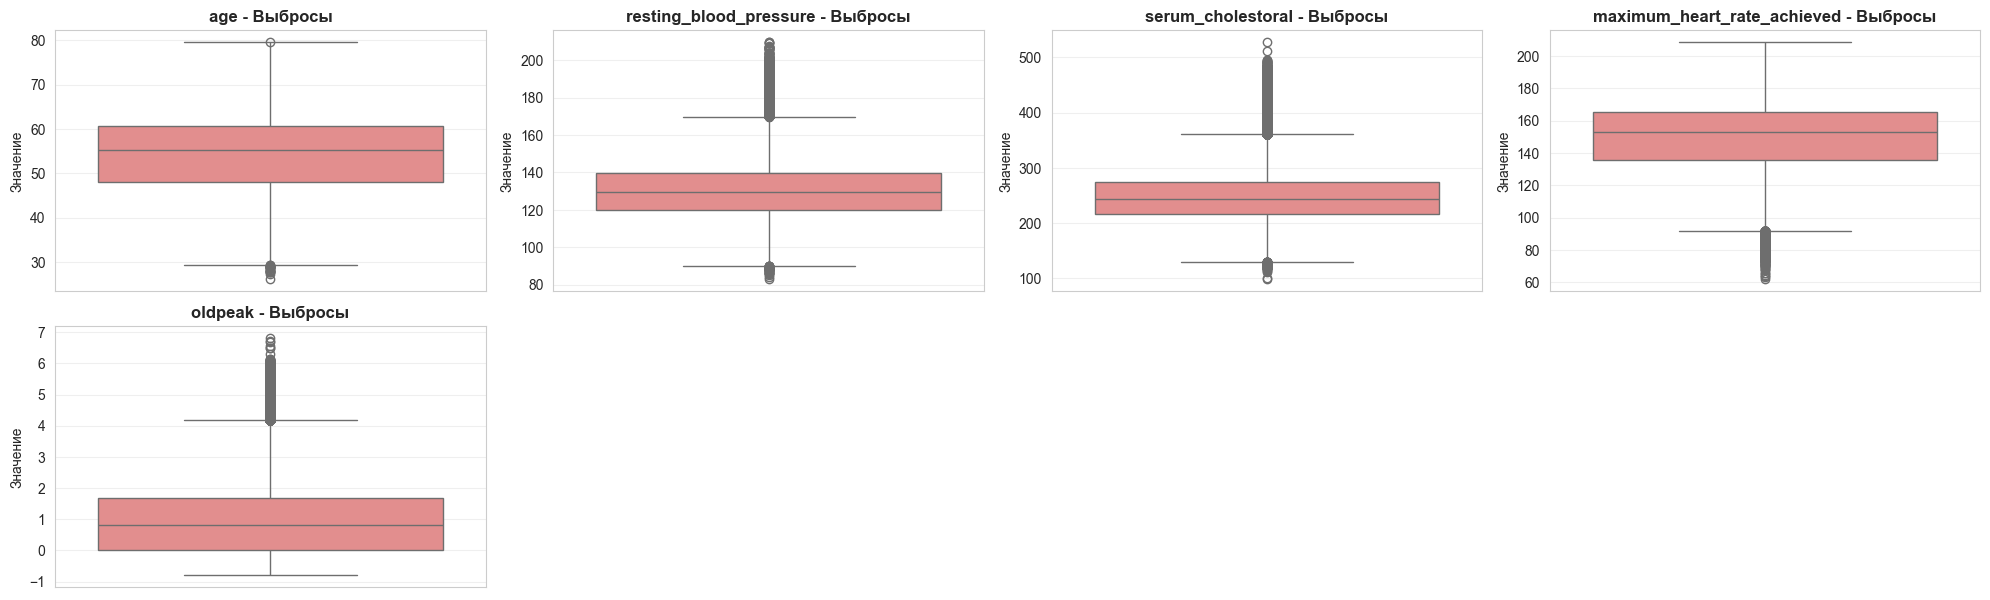

In [13]:
plt.figure(figsize=(20, 12))

# Боксплоты
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)

    sns.boxplot(y=ha_df[col], color='lightcoral')

    plt.title(f'{col} - Выбросы', fontsize=12, fontweight='bold')
    plt.ylabel('Значение')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

1. **age (возраст)**
- Возраст имеет почти нормальное распределение с небольшим правым скосом и несколькими выбросами. Посмотрим на выбросы подробнее. 

2. **resting_blood_pressure (артериальное давление в состоянии покоя)**
- Распределение бимодальное или мультимодальное — видны несколько пиков. Это может указывать на наличие подгрупп в данных. Можно данный признак на подруппы, но пока делать этого не будем. 
- Много выбросов как сверху, так и снизу. Требуется дополнительная очистка.

3. **serum_cholestoral (уровень холестерина в крови mg/dl)**
- Чётко выраженный правый хвост — много пациентов с высоким холестерином (>300 мг/дл).Требуется логарифмирование, чтобы приблизить распределение к нормальному.
- Очень много выбросов сверху (до 500+ мг/дл) — крайне высокие уровни холестерина.
Снизу выбросов почти нет — минимальное значение ~98, что физиологично. Необходимо также провести очистку от выбросов.

4. **maximum_heart_rate_achieved (максимальная частота сердечных сокращений)**
- Максимальная ЧСС имеет хорошее приближение к нормальному распределению. Выбросы снизу могут быть клинически интересны — их стоит изучить отдельно.

5. **oldpeak (депрессия сегмента ST, вызванная физической нагрузкой, относительно состояния покоя)**
- Не нормален, сильно скошен. 
- Содержит отрицательные значения. Они шумовые, поэтому удалим их или заменим на 0.
- Требует логарифмирования, либо обработки как категориального признака.

In [14]:
# Посмотрим потенциальные выбросы в признаке 'age'
ha_df[ha_df['age'] < 30].T

,1384,17757,20807,24480,46601,84377,105836,107132,117167,118516,...,482571,492528,535792,539541,540160,550552,557941,564130,583037,587142
ID,1384.000000,17757.000000,20807.000000,24480.000000,46601.000000,84377.000000,105836.000000,107132.000000,117167.000000,118516.000000,...,482571.000000,492528.000000,535792.000000,539541.000000,540160.000000,550552.000000,557941.000000,564130.000000,583037.000000,587142.000000
age,28.611060,27.763509,29.624094,29.393538,27.809395,28.166359,29.974820,29.961938,28.798376,29.172952,...,29.250955,29.515228,26.061695,29.710057,29.143540,28.747586,29.458872,29.589874,27.688442,29.342503
sex,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
chest,4.000000,4.000000,1.757130,1.696369,1.720134,3.000000,4.000000,4.000000,3.000000,1.953825,...,3.000000,1.112751,3.000000,3.000000,1.273273,4.000000,3.000000,4.000000,3.000000,3.000000
resting_blood_pressure,129.162265,99.609688,122.741697,137.838632,128.939725,131.146657,130.946445,142.319517,154.862258,120.773316,...,101.156075,118.456575,141.855605,140.248636,136.807415,122.414153,118.193985,139.038785,136.515770,145.041955
serum_cholestoral,219.878330,223.416434,220.479515,225.370182,211.358932,260.061076,277.552614,250.463271,226.037772,235.329391,...,231.082865,340.727220,236.184814,207.035064,250.875659,185.048554,207.195603,301.954469,234.095802,245.580083
fasting_blood_sugar,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
resting_electrocardiographic_results,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
maximum_heart_rate_achieved,181.962789,182.263660,176.704632,190.407124,178.267244,156.739740,166.695335,181.139738,171.015224,183.808306,...,171.656644,160.830195,184.076956,155.888976,182.254236,175.941753,160.664431,182.659051,170.152654,176.293910
exercise_induced_angina,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


Возраст пациентов, попавших в потенциальные выбросы в данном признаке, вполне корректен, как и данные в других признаках. Хорошие примеры в более молодой категории. Их наличие поможет модели научиться распознавать ранние признаки болезни даже у молодых. Всех пациентов оставляем в датасете.

In [15]:
# Посмотрим потенциальные выбросы в признаке 'resting_blood_pressure'
ha_df[ha_df['resting_blood_pressure'] > 170].T

,23,43,57,63,114,142,157,223,270,294,...,599823,599838,599858,599873,599874,599935,599955,599961,599970,599999
ID,23.000000,43.000000,57.000000,63.000000,114.000000,142.000000,157.000000,223.000000,270.000000,294.000000,...,599823.000000,599838.000000,599858.000000,599873.000000,599874.000000,599935.000000,599955.000000,599961.000000,599970.000000,599999.000000
age,43.058975,70.734921,41.737465,35.521136,56.010238,68.004752,60.458694,59.719420,66.956327,42.111329,...,62.931298,54.681457,40.924777,72.829487,48.462410,63.019978,48.522631,67.667267,60.378051,62.166853
sex,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
chest,1.995429,4.000000,1.463197,3.000000,4.000000,4.000000,4.000000,1.969717,3.000000,4.000000,...,4.000000,3.000000,2.012288,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000
resting_blood_pressure,194.120833,182.234045,177.045518,180.868688,177.317986,172.498990,173.345494,177.298502,182.928873,187.636098,...,170.831074,178.422264,174.378717,171.382370,172.719010,170.121143,179.123488,193.536230,177.951593,173.197072
serum_cholestoral,212.535708,213.774538,355.143592,237.309413,205.156115,227.542602,254.888525,207.409745,360.065459,196.419274,...,272.978272,157.929119,313.879588,286.579025,279.113998,269.754367,208.385709,208.409340,183.501090,229.909506
fasting_blood_sugar,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
resting_electrocardiographic_results,2.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,2.000000,2.000000,0.000000,0.000000,2.000000,2.000000,0.000000,2.000000,0.000000
maximum_heart_rate_achieved,185.872258,110.613754,160.535109,192.922503,187.930904,145.990209,104.240894,115.381601,97.912628,133.122408,...,136.147525,165.832874,137.910756,181.167767,171.335243,110.035451,128.161816,145.837112,169.283546,160.233072
exercise_induced_angina,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


Всего таких пациентов: 20 847 (это ~3.5% от общего числа (600 000)) - немало.
Это не единичные аномалии, а целая подгруппа пациентов с тяжёлой гипертензией.
Это не выбросы, а реальные пациенты, многие из которых имеют сопутствующие заболевания (ИБС, ишемия, высокий холестерин) (по крайней мере по большей части). Тем не менее, для использования логистической регрессии придется немного их обрезать. 

In [16]:
# Посмотрим потенциальные выбросы в признаке 'serum_cholestoral'
ha_df[ha_df['serum_cholestoral'] > 400].T

,102,286,439,790,811,1052,1207,1353,1385,1488,...,598363,598373,598620,599107,599282,599308,599356,599474,599604,599878
ID,102.000000,286.000000,439.000000,790.000000,811.000000,1052.000000,1207.000000,1353.000000,1385.000000,1488.000000,...,598363.000000,598373.000000,598620.000000,599107.000000,599282.000000,599308.000000,599356.000000,599474.000000,599604.000000,599878.000000
age,38.668318,66.610294,61.278156,37.431677,51.645175,44.724242,42.989630,55.773270,68.022973,59.550015,...,44.734917,41.662244,53.436105,49.693513,39.384290,50.337020,44.878784,58.014963,67.258764,63.675751
sex,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
chest,4.000000,4.000000,1.805126,1.949022,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,2.522788,1.189395,3.000000,1.926135,4.000000,4.000000
resting_blood_pressure,127.964985,140.566935,148.213168,153.930699,119.353367,166.735521,138.370999,139.244164,128.455118,137.674495,...,129.322309,129.667032,129.282091,163.278869,129.202566,176.861233,109.976677,131.449373,141.239521,112.467171
serum_cholestoral,418.733321,404.039834,474.838579,438.114814,441.986618,404.006814,401.663456,411.321094,417.138523,436.120579,...,417.301140,400.767632,406.305078,421.766268,406.523300,461.260342,402.781074,453.496954,401.624197,413.681338
fasting_blood_sugar,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
resting_electrocardiographic_results,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,2.000000,2.000000
maximum_heart_rate_achieved,143.149867,136.534535,176.880110,171.077398,155.990699,193.271104,142.668794,147.443092,156.092265,153.951336,...,167.702853,163.278861,139.902868,104.528980,185.985626,90.000807,179.579188,161.767476,120.636958,163.763677
exercise_induced_angina,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000


В данном признаке ситуация аналогична артериальному давлению. Подобные значения признака могут быть реальными, однако для уменьшения влияния выбросов на модель логистической регрессии немного обрежем их количество. Также признак прологарифмируем.


In [17]:
# Посмотрим потенциальные выбросы в признаке 'maximum_heart_rate_achieved'
ha_df[ha_df['maximum_heart_rate_achieved'] < 90].T

,98,600,1137,1168,1185,1312,1469,1475,1684,1717,...,598413,598457,598963,599135,599152,599558,599630,599678,599975,599991
ID,98.000000,600.000000,1137.000000,1168.000000,1185.000000,1312.000000,1469.000000,1475.000000,1684.000000,1717.000000,...,598413.000000,598457.000000,598963.000000,599135.000000,599152.000000,599558.000000,599630.000000,599678.000000,599975.000000,599991.000000
age,54.088533,49.113682,49.888837,69.233375,55.912894,61.067329,68.140309,62.398951,55.284755,56.243220,...,48.250047,40.699534,43.166100,39.900480,55.781544,41.209879,54.791295,55.229615,70.963388,51.314281
sex,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
chest,4.000000,3.000000,4.000000,3.000000,4.000000,2.545686,4.000000,1.167247,2.170435,4.000000,...,1.946992,1.236863,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,4.000000,3.000000
resting_blood_pressure,121.594198,122.175092,168.588833,124.606981,108.106353,138.817433,124.638153,104.811044,114.559582,136.879472,...,106.282004,121.070894,142.149340,123.155119,127.924716,130.989671,128.118993,136.423596,112.198966,120.894994
serum_cholestoral,330.004909,281.410421,277.202249,162.833907,275.528963,182.399081,198.168764,163.714139,362.981212,218.537189,...,235.097334,145.928995,154.548435,162.845283,277.986709,357.931550,236.404740,241.392752,182.432521,263.964852
fasting_blood_sugar,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
resting_electrocardiographic_results,2.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,2.000000,...,2.000000,0.000000,2.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000
maximum_heart_rate_achieved,84.495885,88.027532,86.456521,87.808838,86.516663,86.765602,76.802281,87.267706,83.765829,89.078063,...,89.392252,88.687631,89.524962,75.337105,84.460943,88.563686,84.218029,76.595750,80.635442,84.536523
exercise_induced_angina,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000


В данном признаке выбросы так же, вероятно, являются реальными клиническими случаями. Возможно это люди с тяжелой ИБС, которые принимают медикаментозную терапию (о ней данных нет). Таких случаев в целом немного, поэтому оставим их в датасете.

In [18]:
# Посмотрим потенциальные выбросы в признаке 'oldpeak'
ha_df[ha_df['oldpeak'] > 4].T

,50,59,118,152,156,226,235,251,304,371,...,599495,599554,599582,599644,599693,599814,599835,599846,599943,599948
ID,50.000000,59.000000,118.000000,152.000000,156.000000,226.000000,235.000000,251.000000,304.000000,371.000000,...,599495.000000,599554.000000,599582.000000,599644.000000,599693.000000,599814.000000,599835.000000,599846.000000,599943.000000,599948.000000
age,57.696717,60.511859,67.594927,57.756406,63.245152,62.950824,58.958501,54.496496,58.896132,73.232605,...,49.423357,52.179131,60.067927,58.642173,52.035227,68.049099,66.053150,57.524654,59.754122,38.352699
sex,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
chest,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,3.000000
resting_blood_pressure,120.009264,105.397406,132.548808,116.598686,114.796191,137.454256,131.654608,128.444471,174.177733,128.493893,...,106.759278,113.628085,138.698012,130.141588,112.322898,114.645053,104.103005,163.767313,122.630468,140.358892
serum_cholestoral,218.513427,280.055497,337.248051,220.274492,328.313506,218.852407,275.068655,196.943980,225.941029,274.624313,...,216.901809,288.736774,217.602672,270.907055,217.222443,245.437757,260.644850,213.648912,251.170501,254.448182
fasting_blood_sugar,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
resting_electrocardiographic_results,0.000000,2.000000,2.000000,0.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,0.000000,2.000000,0.000000,0.000000
maximum_heart_rate_achieved,135.791668,101.674790,162.276889,132.591755,135.519952,150.160615,137.146693,160.994450,145.592450,175.946782,...,163.804313,182.055558,135.301393,139.812229,115.578762,115.743581,159.729560,163.184483,162.794376,90.509848
exercise_induced_angina,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000


В данном случае выбросы снова реальные пациенты с тяжёлой ишемией миокарда, многие из которых имеют:
- Высокий холестерин
- Обратимые дефекты перфузии (thal=7)
- Диагноз ИБС (class=1).
Пациентов оставим в датасете. Прологарифмируем признак.

## Категориальные переменные

In [19]:
# Описательная статистика
# Все признаки, являющиеся категориальными имеют тип данных int (кроме 'chest')
# Признак ID не является информативным - его удалим при очистке
# Они уже приведены к числовому типу
ha_df.describe(include='int').T

,count,mean,std,min,25%,50%,75%,max
ID,600000.0,299999.500000,173205.225094,0.0,149999.75,299999.5,449999.25,599999.0
sex,600000.0,0.677447,0.467454,0.0,0.00,1.0,1.00,1.0
fasting_blood_sugar,600000.0,0.150757,0.357812,0.0,0.00,0.0,0.00,1.0
resting_electrocardiographic_results,600000.0,1.020148,0.994204,0.0,0.00,2.0,2.00,2.0
exercise_induced_angina,600000.0,0.333502,0.471464,0.0,0.00,0.0,1.00,1.0
slope,600000.0,1.596033,0.629821,1.0,1.00,2.0,2.00,3.0
number_of_major_vessels,600000.0,0.681303,0.950669,0.0,0.00,0.0,1.00,3.0
thal,600000.0,4.711378,1.934766,3.0,3.00,3.0,7.00,7.0
class,600000.0,0.444185,0.496875,0.0,0.00,0.0,1.00,1.0


In [20]:
# Признак 'chest' должен быть категориальным (от 1 до 4), но в данный момент в нем есть дробные значения
print(ha_df['chest'].unique())

[4.       1.741596 1.954609 ... 1.680331 1.949117 1.295676]


In [21]:
# Приведем данный признак к типу int (целые цисла) с округлением, для того, чтобы он стал обозначать категории
ha_df_copy = ha_df
ha_df_copy['chest'] = ha_df_copy['chest'].round().astype(int)
print(ha_df_copy['chest'].unique())

[ 4  2  3  1  0 -1]


Появились отрицательные значения, такого быть не должно (шкала от 0 до 4)

In [22]:
# Заменяем все отрицательные значения на 0
ha_df_copy['chest'] = ha_df_copy['chest'].clip(lower=0)
print(ha_df_copy['chest'].unique())


[4 2 3 1 0]


Теперь в значениях признака все корректно

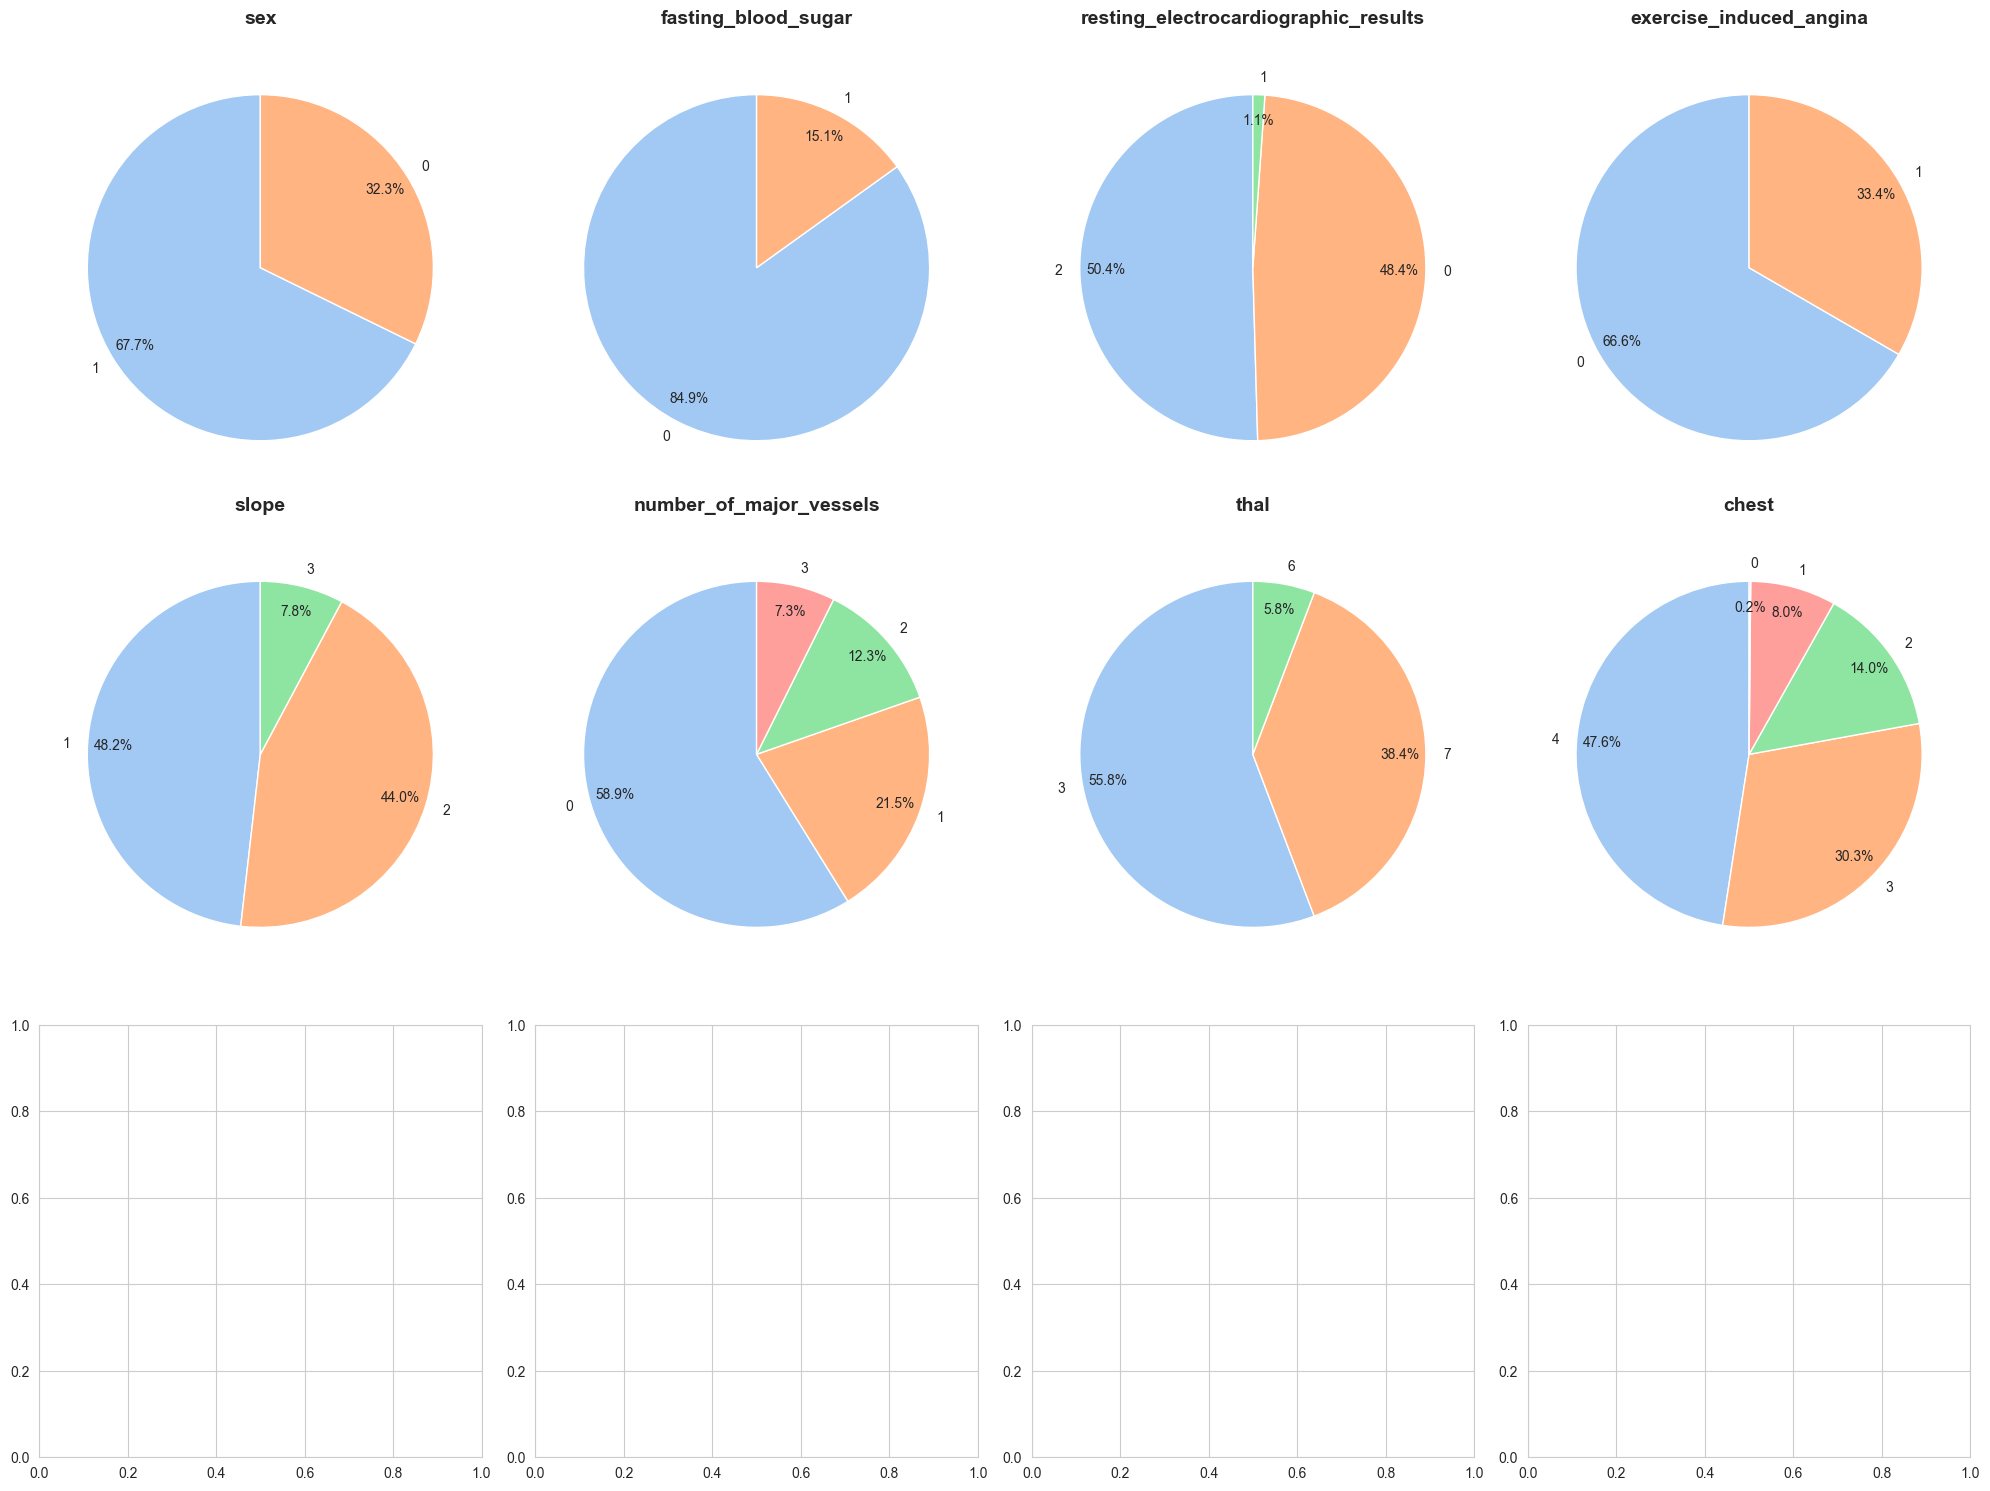

In [23]:
# Построим графики для категориальных признаков
sns.set_style("whitegrid")

# Список категориальных столбцов (без class)
categorical_cols = ['sex', 
                    'fasting_blood_sugar',
                    'resting_electrocardiographic_results', 
                    'exercise_induced_angina', 
                    'slope', 
                    'number_of_major_vessels', 
                    'thal',
                    'chest']

# Создаем фигуру с подграфиками
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    # Считаем количество каждой категории
    counts = ha_df_copy[col].value_counts()

    # Цветовая палитра
    colors = sns.color_palette('pastel', len(counts))

    # Pie chart
    wedges, texts, autotexts = axes[i].pie(counts.values, labels=counts.index,
                                           autopct='%1.1f%%', colors=colors,
                                           startangle=90, pctdistance=0.85)

    # Заголовок
    axes[i].set_title(f'{col}', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

1. **sex (пол)**
- 0 = женщина, 1 = мужчина
- Распределение:
Мужчины: 67.7%
Женщины: 32.3%
- В датасете преобладают мужчины.

2. **fasting_blood_sugar (анализ глюкозы в крови натощак (> 120 mg/dl))**
- 0 = нет, 1 = да
- Распределение:
Норма (<120): 84.9%
Повышенный (>120): 15.1%
- У большинства пациентов уровень сахара в норме. Только ~15% имеют повышенный сахар натощак — это может указывать на преддиабет или диабет 2 типа, который является фактором риска сердечно-сосудистых заболеваний.

3. **resting_electrocardiographic_results (ЭКГ в покое)**
- Значения: 0,1,2;
- Распределение:
Норма (0): 48.4%
(1): 1.1% 
(2): 50.4%
- Почти половина пациентов имеют нарушения на ЭКГ. Это могут быть изменения реполяризации, блокады, рубцы и т.д.

4. **exercise_induced_angina (стенокардия при нагрузке)**
- 0 = нет, 1 = да
- Распределение:
Нет стенокардии: 66.6%
Есть стенокардия: 33.4%
- У трети пациентов боль в груди возникает именно при физической нагрузке — классический признак стабильной стенокардии. Это важный диагностический критерий.

5. **slope (наклон сегмента ST при нагрузке)**
- 1 = восходящий, 2 = горизонтальный, 3 = нисходящий
- Распределение:
Восходящий (1): 48.2%
Горизонтальный (2): 44.0%
Нисходящий (3): 7.8%
- Восходящий наклон (1) — наименее опасный, часто встречается у здоровых.
- Горизонтальный (2) — умеренно опасный, указывает на ишемию.
- Нисходящий (3) — самый опасный, сильно связан с тяжёлой ИБС.
- Почти у половины пациентов — благоприятный наклон, но у 44% — уже есть признаки ишемии (горизонтальный), а у 8% — серьёзные нарушения (нисходящий).

6. **number_of_major_vessels (количество поражённых крупных сосудов)**
- 0, 1, 2, 3 — сколько из трёх основных коронарных артерий сужены >50%
- Распределение:
0 сосудов: 58.9%
1 сосуд: 21.5%
2 сосуда: 12.3%
3 сосуда: 7.3%
- Более половины пациентов не имеют значимого поражения крупных сосудов — возможно, у них микрососудистая болезнь или спазм.
- У ~41% есть поражение хотя бы одного сосуда — это подтверждённая ИБС.
- У 7.3% — поражение всех трёх сосудов.

7. **thal (перфузия миокарда)**
- 3 = норма, 6 = фиксированный дефект, 7 = обратимый дефект
- Распределение:
Норма (3): 55.8%
Фиксированный дефект (6): 5.8%
Обратимый дефект (7): 38.4%
- Обратимый дефект (7) —  означает, что при нагрузке участок сердца недополучает кровь, но в покое всё восстанавливается. Это классический признак стабильной стенокардии.
- Фиксированный дефект (6) — рубец или инфаркт в анамнезе.
- Норма (3) — нет нарушений перфузии.
- Почти 40% пациентов имеют обратимый дефект — это высокая доля, подтверждающая распространённость ишемии в выборке.

8. **chest (тип боли в груди)**
- 0 = Нет данных
1 = Типичная стенокардия (боль при нагрузке, проходит в покое/нитроглицерин)
2 = Атипичная стенокардия (неполные симптомы)
3 = Неангинозная боль (боль в груди, но не связанная с сердцем)
4 = Бессимптомное течение (нет боли, но есть ишемия или болезнь)
- Почти половина пациентов (47.6%) имеют бессимптомное течение (chest=4) — они не чувствуют боли в груди, несмотря на наличие заболевания.

## Таргетная (целевая) переменная

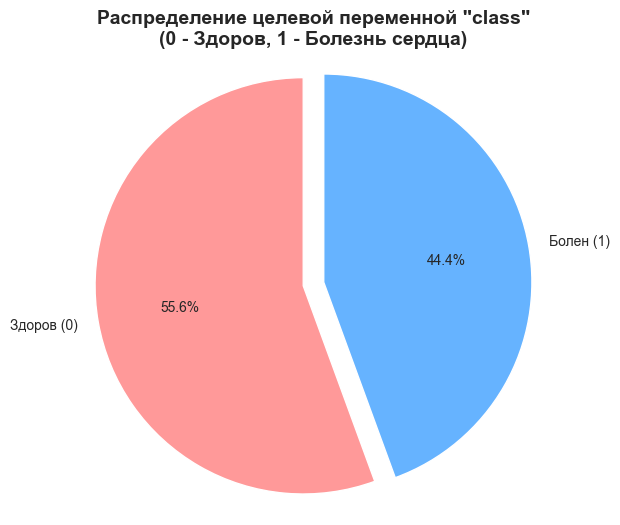

Абсолютные значения:
class
0    333489
1    266511
Name: count, dtype: int64

Процентное соотношение:
class
0    55.5815
1    44.4185
Name: proportion, dtype: float64


In [24]:
import matplotlib.pyplot as plt

# Настройка фигуры
plt.figure(figsize=(6, 6))

# Построение круговой диаграммы
plt.pie(
    ha_df_copy['class'].value_counts(), 
    labels=['Здоров (0)', 'Болен (1)'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999', '#66b3ff'], 
    explode=(0.05, 0.05)
)

plt.title('Распределение целевой переменной "class"\n(0 - Здоров, 1 - Болезнь сердца)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

print("Абсолютные значения:")
print(ha_df['class'].value_counts())
print("\nПроцентное соотношение:")
print(ha_df['class'].value_counts(normalize=True) * 100)

Датасет хорошо сбалансирован. Соотношение классов примерно 56% к 44%.
Метрика Accuracy будет информативной (но посмотрим и на Precision/Recall/F1).
Модель не будет иметь сильного смещения в сторону одного класса.

# Предобработка данных

## Удаление лишних признаков

In [25]:
# Удаляем признак ID 

ha_df_clr = ha_df_copy.copy()
ha_df_clr.drop('ID', axis=1, inplace=True)

## Логарифмирование числовых признаков

In [28]:
# Логарифмируем сильно скошенные признаки
skewed_cols = ['serum_cholestoral', 'oldpeak']
for col in skewed_cols:
    if col in ha_df_clr.columns:
        ha_df_clr[f'{col}_log'] = np.log1p(ha_df_clr[col])

In [29]:
ha_df_clr.head().T

,0,1,2,3,4
age,49.207124,53.628425,49.591426,58.991445,51.053602
sex,0.000000,1.000000,1.000000,1.000000,1.000000
chest,4.000000,2.000000,4.000000,4.000000,2.000000
resting_blood_pressure,162.996167,130.233730,146.999012,112.369143,138.032047
serum_cholestoral,181.108682,276.474630,223.300517,187.245501,238.482868
fasting_blood_sugar,0.000000,0.000000,1.000000,0.000000,0.000000
resting_electrocardiographic_results,0.000000,2.000000,2.000000,0.000000,0.000000
maximum_heart_rate_achieved,148.227858,152.917139,102.352090,158.164750,172.540828
exercise_induced_angina,1.000000,0.000000,1.000000,1.000000,0.000000
oldpeak,0.944547,0.119070,1.616747,0.000000,1.150464


In [30]:
ha_df_clr_log = ha_df_clr.copy()

# Создаем словарь соответствия: старый столбец -> новый логарифмированный
log_mapping = {
    'serum_cholestoral': 'serum_cholestoral_log',
    'oldpeak': 'oldpeak_log'
}

# Заменяем старые столбцы на новые
for old_col, new_col in log_mapping.items():
    if new_col in ha_df_clr_log.columns:
        ha_df_clr_log[old_col] = ha_df_clr_log[new_col]
        print(f"Данные из '{new_col}' перенесены в '{old_col}'.")

# Удаляем ненужные теперь столбцы с суффиксом _log
cols_to_drop = list(log_mapping.values())
ha_df_clr_log.drop(columns=cols_to_drop, inplace=True)
print(f"Удалены временные столбцы: {cols_to_drop}")

# Финальная проверка
print("Первые 5 строк после очистки:")
print(ha_df_clr_log[['serum_cholestoral', 'oldpeak']].head())

Данные из 'serum_cholestoral_log' перенесены в 'serum_cholestoral'.
Данные из 'oldpeak_log' перенесены в 'oldpeak'.
Удалены временные столбцы: ['serum_cholestoral_log', 'oldpeak_log']
Первые 5 строк после очистки:
   serum_cholestoral   oldpeak
0           5.204604  0.665029
1           5.625730  0.112498
2           5.412987  0.961932
3           5.237747  0.000000
4           5.478482  0.765684


## Очистка от выбросов

In [31]:
def clean_outliers_iqr(df, column_name):
    """
    Функция для очистки выбросов методом IQR (Winsorizing).
    Заменяет значения за пределами [Q1 - 1.5*IQR, Q3 + 1.5*IQR] на границы этого диапазона.
    """
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # Вычисляем границы
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Для давления и холестерина добавим физиологические ограничения
    if column_name == 'resting_blood_pressure':
        lower_bound = max(lower_bound, 80)   # Давление ниже 80 маловероятно для этой выборки
        upper_bound = min(upper_bound, 200)  # Давление выше 200 - критическое, лучше обрезать
        
    elif column_name == 'serum_cholesterol':
        lower_bound = max(lower_bound, 100)  # Холестерин ниже 100 редкость
        upper_bound = min(upper_bound, 400)  # Выше 400 - экстремальные случаи

    # Применяем обрезку (clip)
    df[f'{column_name}_clean'] = df[column_name].clip(lower=lower_bound, upper=upper_bound)
    
    # Считаем статистику
    original_outliers_low = (df[column_name] < lower_bound).sum()
    original_outliers_high = (df[column_name] > upper_bound).sum()
    
    print(f" Обработан признак: {column_name}")
    print(f"   Границы IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   Заменено выбросов снизу: {original_outliers_low}")
    print(f"   Заменено выбросов сверху: {original_outliers_high}")
    print("-" * 30)
    
    return df

# Создаем копию датасета
ha_df_clr_log_2 = ha_df_clr_log.copy()

# Очищаем нужные признаки
cols_to_clean = ['resting_blood_pressure', 'serum_cholestoral']

for col in cols_to_clean:
    ha_df_clr_log_2 = clean_outliers_iqr(ha_df_clr_log_2, col)


 Обработан признак: resting_blood_pressure
   Границы IQR: [89.94, 169.90]
   Заменено выбросов снизу: 45
   Заменено выбросов сверху: 21084
------------------------------
 Обработан признак: serum_cholestoral
   Границы IQR: [5.03, 5.97]
   Заменено выбросов снизу: 3455
   Заменено выбросов сверху: 7837
------------------------------


In [32]:
# Проверка результата
print(" Статистика до очистки:")
display(ha_df_clr_log_2[cols_to_clean].describe().loc[['min', '25%', '50%', 'mean', '75%', 'max']].T)

print("\n Статистика после очистки:")
clean_cols = [f'{c}_clean' for c in cols_to_clean]
display(ha_df_clr_log_2[clean_cols].describe().loc[['min', '25%', '50%', 'mean', '75%', 'max']].T)

 Статистика до очистки:


,min,25%,50%,mean,75%,max
resting_blood_pressure,82.918527,119.924094,129.727941,131.340485,139.915216,209.673650
serum_cholestoral,4.598410,5.382088,5.502212,5.503377,5.618027,6.270527



 Статистика после очистки:


,min,25%,50%,mean,75%,max
resting_blood_pressure_clean,89.937411,119.924094,129.727941,131.102711,139.915216,169.901899
serum_cholestoral_clean,5.028181,5.382088,5.502212,5.503020,5.618027,5.971934


## Матрица корреляций

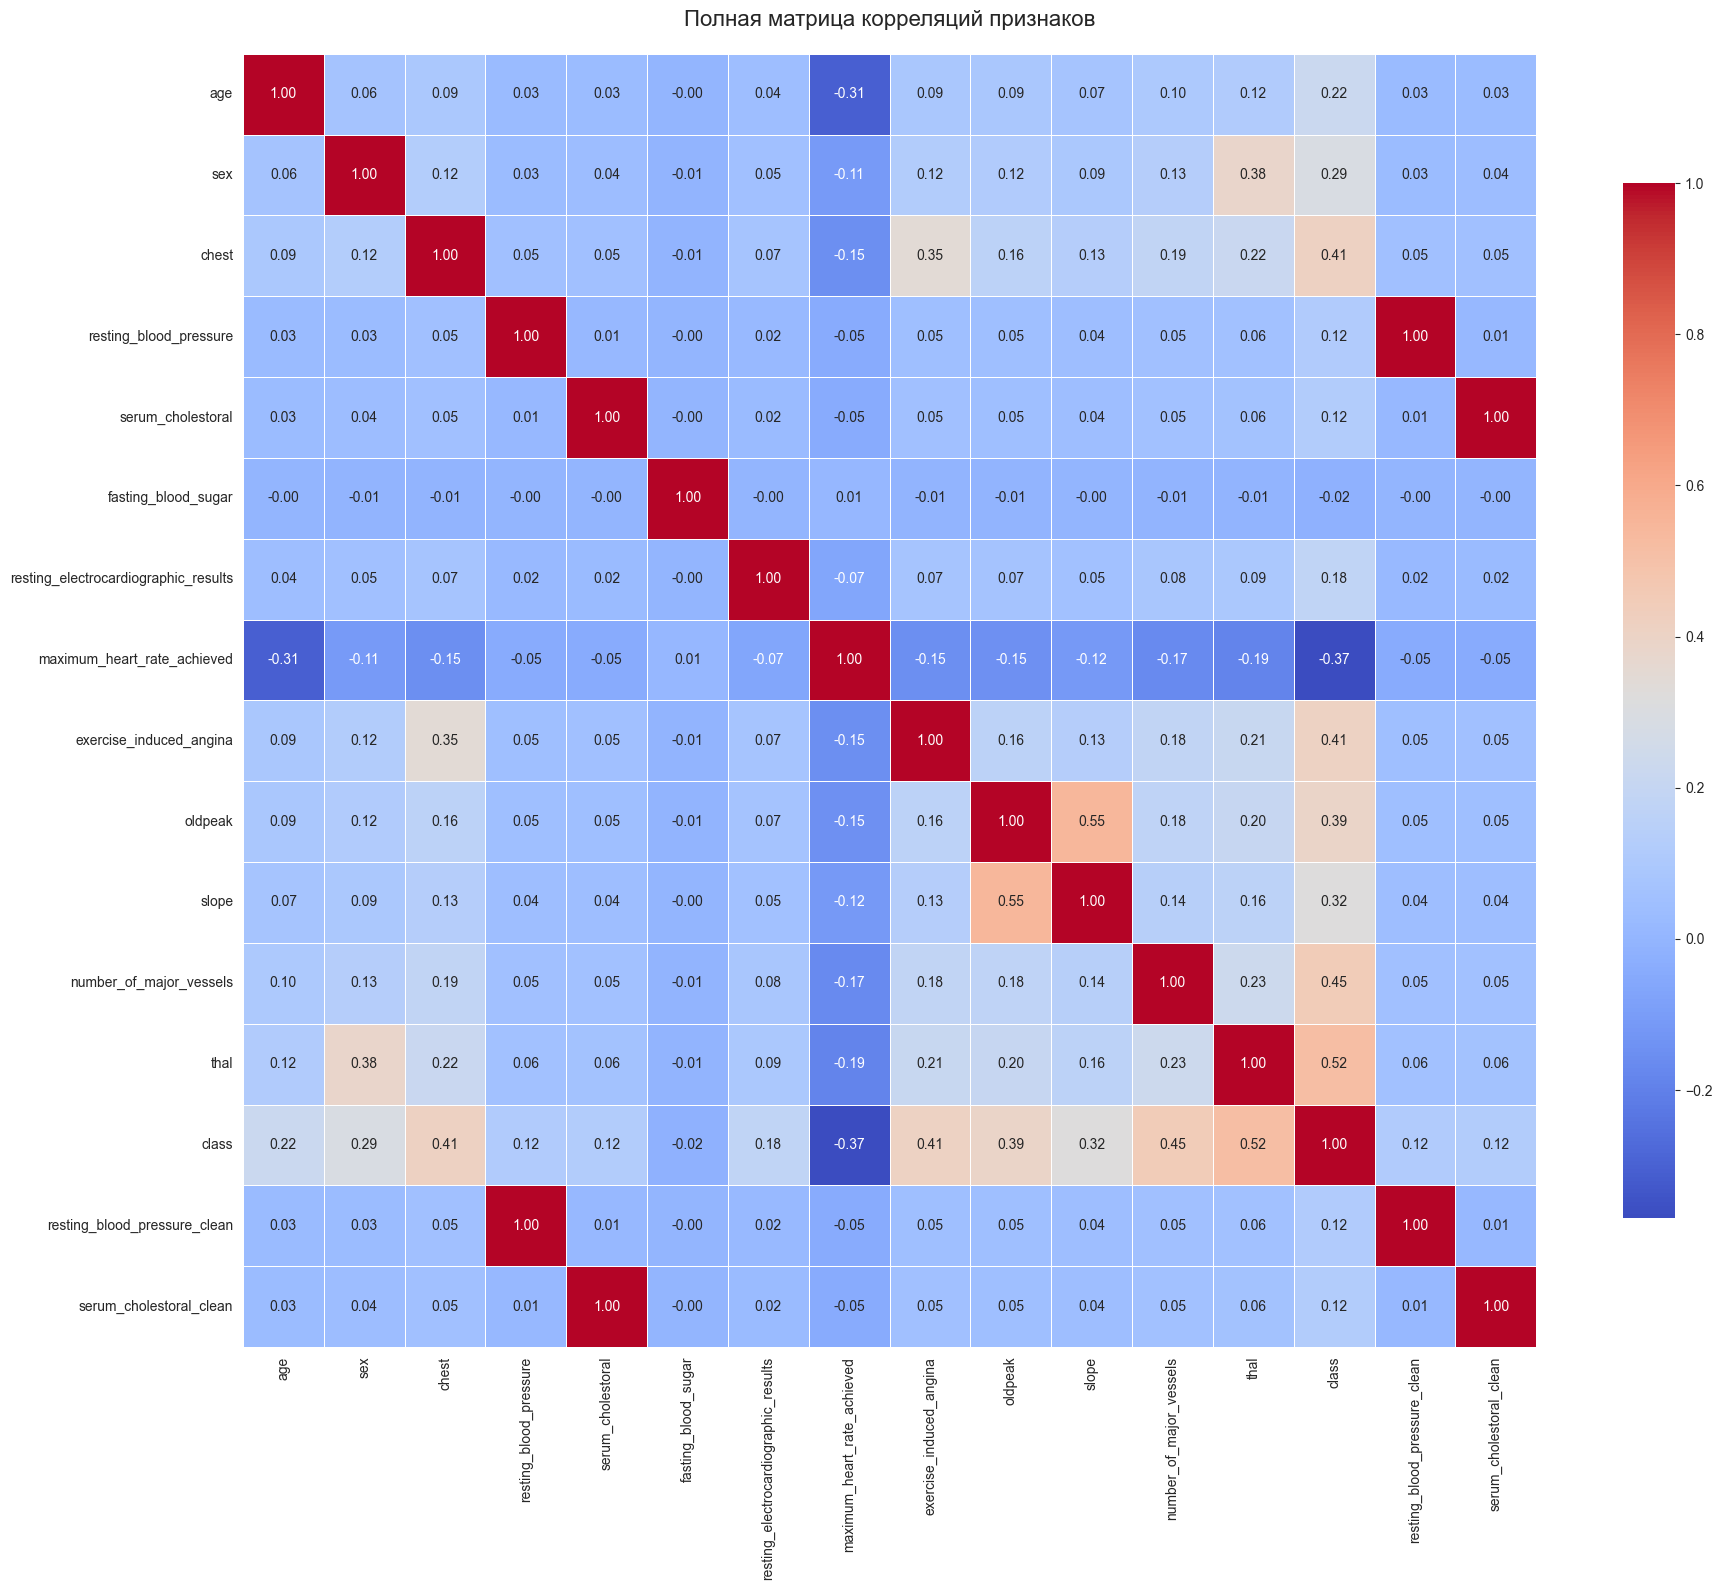

In [33]:
corr_matrix = ha_df_clr_log_2.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title('Полная матрица корреляций признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

**Выводы**:
- Самым сильным предиктором заболевания является признак thal (результат теста перфузии) с коэффициентом корреляции +0.52. Это означает, что наличие дефектов кровоснабжения сердца — самый верный индикатор болезни.
- Следом за ним идет группа очень важных признаков с корреляцией около +0.40–0.45:
number_of_major_vessels (количество пораженных сосудов);
chest (тип боли в груди);
exercise_induced_angina (стенокардия при нагрузке).
- Также высокую значимость имеют oldpeak (депрессия сегмента ST, +0.39) и slope (наклон ST, +0.32).
- Сильная отрицательная связь у таргета и признака maximum_heart_rate_achieved (-0.37): чем ниже максимальный пульс пациент может достичь при нагрузке, тем выше вероятность болезни.
- Пол (sex) и возраст (age) положительно влияют на риск (+0.29 и +0.22 соответственно).
- Признаки resting_blood_pressure и serum_cholesterol показывают слабую связь с болезнью (около +0.12), а уровень сахара натощак (fasting_blood_sugar) практически не влияет на результат (-0.02).
- Важно отметить, что очищенные от выбросов признаки (_clean) сохранили те же самые связи с целевой переменной, что и оригиналы. Это подтверждает, что процедура очистки прошла успешно: мы убрали шум, но не потеряли полезную информацию.
- Среди самих признаков есть заметные внутренние связи: например, oldpeak и slope коррелируют между собой (+0.55), как и thal с количеством пораженных сосудов (+0.52). Для деревьев решений это не проблема, но для линейной регрессии эти пары признаков несут похожую информацию. Проверим для них VIF.

In [34]:
# Расчёт VIF (выявляем наличие скрытой мультиколлинеарности)

def calculate_vif(X):
    """Рассчитывает VIF для каждого признака"""
    vif_data = pd.DataFrame()
    vif_data['Признак'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_data['Статус'] = vif_data['VIF'].apply(
        lambda x: '✅ OK' if x < 5 else ('⚠️ Высокий' if x < 10 else '❌ Критический')
    )
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Выбираем признаки для VIF анализа
X = ha_df_clr_log_2

vif_results = calculate_vif(X)
print(vif_results.to_string(index=False))

                             Признак           VIF        Статус
             serum_cholestoral_clean 403284.284115 ❌ Критический
                   serum_cholestoral 401335.735566 ❌ Критический
        resting_blood_pressure_clean   7636.818469 ❌ Критический
              resting_blood_pressure   7187.000900 ❌ Критический
         maximum_heart_rate_achieved     48.765701 ❌ Критический
                                 age     38.753747 ❌ Критический
                               chest     14.948637 ❌ Критический
                               slope     10.744186 ❌ Критический
                                thal     10.207976 ❌ Критический
                               class      4.290301          ✅ OK
                                 sex      3.676478          ✅ OK
                             oldpeak      3.473968          ✅ OK
resting_electrocardiographic_results      2.120319          ✅ OK
             number_of_major_vessels      1.891624          ✅ OK
             exercise_ind

## Промежуточная очистка данных

In [35]:
ha_df_drop = ha_df_clr_log_2.copy()
# Удаляем дубли, возникшие после очистки
cols_to_drop = [
    'serum_cholestoral',       
    'resting_blood_pressure'
]

ha_df_drop.drop(columns=cols_to_drop, inplace=True)

print(f"Удалено {len(cols_to_drop)} дублирующих столбцов.")
print("Оставшиеся столбцы:", ha_df_drop.columns.tolist())

Удалено 2 дублирующих столбцов.
Оставшиеся столбцы: ['age', 'sex', 'chest', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal', 'class', 'resting_blood_pressure_clean', 'serum_cholestoral_clean']


In [36]:
ha_df_drop.T

,0,1,2,3,4,5,6,7,8,9,...,599990,599991,599992,599993,599994,599995,599996,599997,599998,599999
age,49.207124,53.628425,49.591426,58.991445,51.053602,61.069909,43.108527,47.204068,55.158454,49.569574,...,45.319736,51.314281,57.956867,50.401016,63.929009,47.832254,42.106575,41.579352,53.716562,62.166853
sex,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
chest,4.000000,2.000000,4.000000,4.000000,2.000000,3.000000,4.000000,4.000000,4.000000,2.000000,...,2.000000,3.000000,4.000000,2.000000,3.000000,4.000000,3.000000,1.000000,4.000000,3.000000
fasting_blood_sugar,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
resting_electrocardiographic_results,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,2.000000,0.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000
maximum_heart_rate_achieved,148.227858,152.917139,102.352090,158.164750,172.540828,112.820336,154.180680,163.239001,102.672796,158.839407,...,173.926436,84.536523,162.814041,108.690668,150.120707,161.831133,178.749408,175.869174,171.195150,160.233072
exercise_induced_angina,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
oldpeak,0.665029,0.112498,0.961932,0.000000,0.765684,0.000000,0.000000,0.000000,0.000000,0.638610,...,1.010584,0.000000,0.784707,0.000000,1.006129,1.423453,1.073386,0.000000,1.388044,1.030948
slope,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,...,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000
number_of_major_vessels,0.000000,0.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,0.000000


## Кодирование категориальных признаков OneHot-методом

In [37]:
# Список категориальных признаков для кодирования
categorical_cols = [
    'sex', 
    'chest', 
    'fasting_blood_sugar', 
    'resting_electrocardiographic_results', 
    'exercise_induced_angina', 
    'slope', 
    'number_of_major_vessels', 
    'thal'
]

# Создаем копию датасета
ha_df_encoded = ha_df_drop.copy() 

# Преобразование в фиктивные переменные с drop_first=True
# drop_first=True удаляет первый столбец для каждого признака, чтобы избежать мультиколлинеарности
ha_df_encoded = pd.get_dummies(
    ha_df_encoded, 
    columns=categorical_cols, 
    drop_first=True, 
    prefix=categorical_cols # Добавляет префиксы, чтобы имена были понятными (например, chest_1, chest_2...)
)

print(f"Было колонок: {len(ha_df.columns)}")
print(f"Стало колонок: {len(ha_df_encoded.columns)}")
print("\nНовые названия колонок:")
print(ha_df_encoded.columns.tolist())

Было колонок: 15
Стало колонок: 22

Новые названия колонок:
['age', 'maximum_heart_rate_achieved', 'oldpeak', 'class', 'resting_blood_pressure_clean', 'serum_cholestoral_clean', 'sex_1', 'chest_1', 'chest_2', 'chest_3', 'chest_4', 'fasting_blood_sugar_1', 'resting_electrocardiographic_results_1', 'resting_electrocardiographic_results_2', 'exercise_induced_angina_1', 'slope_2', 'slope_3', 'number_of_major_vessels_1', 'number_of_major_vessels_2', 'number_of_major_vessels_3', 'thal_6', 'thal_7']


In [38]:
ha_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 22 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   age                                     600000 non-null  float64
 1   maximum_heart_rate_achieved             600000 non-null  float64
 2   oldpeak                                 600000 non-null  float64
 3   class                                   600000 non-null  int64  
 4   resting_blood_pressure_clean            600000 non-null  float64
 5   serum_cholestoral_clean                 600000 non-null  float64
 6   sex_1                                   600000 non-null  bool   
 7   chest_1                                 600000 non-null  bool   
 8   chest_2                                 600000 non-null  bool   
 9   chest_3                                 600000 non-null  bool   
 10  chest_4                                 6000

In [39]:
# Находим все столбцы с типом bool и преобразуем их в int64
bool_columns = ha_df_encoded.select_dtypes(include=['bool']).columns
ha_df_encoded[bool_columns] = ha_df_encoded[bool_columns].astype('int64')
ha_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 22 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   age                                     600000 non-null  float64
 1   maximum_heart_rate_achieved             600000 non-null  float64
 2   oldpeak                                 600000 non-null  float64
 3   class                                   600000 non-null  int64  
 4   resting_blood_pressure_clean            600000 non-null  float64
 5   serum_cholestoral_clean                 600000 non-null  float64
 6   sex_1                                   600000 non-null  int64  
 7   chest_1                                 600000 non-null  int64  
 8   chest_2                                 600000 non-null  int64  
 9   chest_3                                 600000 non-null  int64  
 10  chest_4                                 6000

In [40]:
# Выбираем признаки для VIF анализа
X = ha_df_encoded

vif_results = calculate_vif(X)
print(vif_results.to_string(index=False))

                               Признак        VIF        Статус
               serum_cholestoral_clean 405.872708 ❌ Критический
                               chest_4 187.467891 ❌ Критический
                               chest_3 119.092860 ❌ Критический
          resting_blood_pressure_clean  57.554821 ❌ Критический
                               chest_2  55.563881 ❌ Критический
           maximum_heart_rate_achieved  50.311869 ❌ Критический
                                   age  39.676659 ❌ Критический
                               chest_1  32.156928 ❌ Критический
                                 class   4.629132          ✅ OK
                                 sex_1   3.703897          ✅ OK
                               oldpeak   3.493458          ✅ OK
                               slope_2   2.695316          ✅ OK
                                thal_7   2.471370          ✅ OK
resting_electrocardiographic_results_2   2.109197          ✅ OK
             exercise_induced_angina_1  

Принимаем решение не удалять признаки из данных, так как они могут быть важны для более сложных моделей, а мультиколлинеарность им не мешает (Randomforest,
Neural Network). Для логистической регрессии попробуем сделать регуляризацию.

## Разделение выборки

In [41]:
ha_df_final = ha_df_encoded.copy()

In [42]:
# Разделяем на тренировочную и тестовую выборки 
X = ha_df_final.drop('class', axis=1)
y = ha_df_final['class']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Стандартизация

In [43]:
# Инициализируем скалер
scaler = StandardScaler()

# Обучаем скалер на тренировочных данных
scaler.fit(X_train) 

# Преобразуем обе выборки, используя параметры, полученные из train
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Размер train: {X_train_scaled.shape}")
print(f"Размер val: {X_val_scaled.shape}")

Размер train: (480000, 21)
Размер val: (120000, 21)


# Построение и оценка моделей машинного обучения

Для решения задачи выбрали три разнородных алгоритма. 
- Логистическая регрессия — простая линейная модель. 
- Случайный лес (Random Forest) — ансамбль деревьев.
- Neural Network - многослойная нейронная сеть.

Для сравнения будем использовать кросс-валидацию (5 фолдов) на тренировочной выборке и финальный тест на отложенной выборке (val).

Ключевые метрики:
- **ROC-AUC** — способность модели различать классы. Показывает вероятность того, что случайно выбранный больной пациент получит более высокий балл риска, чем здоровый.
- **Accuracy** — общая доля правильных ответов. Показывает, какой процент всех пациентов (и здоровых, и больных) модель классифицировала верно.
- **Precision** — точность положительных прогнозов. Показывает, какую долю из тех, кого модель назвала больными, действительно являются больными. 
- **Recall** — полнота выявления. Показывает, какую долю реально больных пациентов мы смогли выявить. Высокий Recall означает, что модель пропускает мало случаев заболевания.

## Логистическая регрессия и случайный лес

In [47]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Словарь моделей
models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000, random_state=42),
    'Случайный лес': RandomForestClassifier(n_estimators=100, random_state=42),
}

scorers = {
    'accuracy': make_scorer(accuracy_score),       
    'roc_auc': make_scorer(roc_auc_score),                            
    'precision': make_scorer(precision_score),     
    'recall': make_scorer(recall_score)            
}

cv_results = {}

for name, model in models.items():
    # Проводим кросс-валидацию на тренировочных данных
    scores = cross_validate(
        model,
        X_train_scaled, y_train,
        cv=cv,
        scoring=scorers,
        return_train_score=False
    )
    
    cv_results[name] = {
        'ROC-AUC (CV)': scores['test_roc_auc'].mean(),      
        'Accuracy (CV)': scores['test_accuracy'].mean(),                
        'Precision (CV)': scores['test_precision'].mean(),  
        'Recall (CV)': scores['test_recall'].mean()         
    }
    
    print(f"\n{name}:")
    print(f"  CV ROC-AUC:   {scores['test_roc_auc'].mean():.3f}")
    print(f"  CV Accuracy:  {scores['test_accuracy'].mean():.3f}")
    print(f"  CV Precision: {scores['test_precision'].mean():.3f}")
    print(f"  CV Recall:    {scores['test_recall'].mean():.3f}")



Логистическая регрессия:
  CV ROC-AUC:   0.886
  CV Accuracy:  0.888
  CV Precision: 0.881
  CV Recall:    0.866

Случайный лес:
  CV ROC-AUC:   0.895
  CV Accuracy:  0.897
  CV Precision: 0.890
  CV Recall:    0.876


Случайный лес превзошел логистическую регрессию по всем метрикам, но с небольшой разницей. Попробуем улучшить модели, подобрав гиперпараметры.

In [ ]:
# Кросс-валидация
cv_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 100, log=True), 
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']), 
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),
        'max_iter': 1000,
        'class_weight': 'balanced', 
        'random_state': 42,
        'n_jobs': -1
    }
    
    model_1 = LogisticRegression(**params)
    # Оптимизируем по ROC-AUC-score
    score = cross_val_score(model_1, X_train_scaled, y_train, cv=cv_opt, scoring='roc_auc', n_jobs=-1).mean()
    return score


# Оптимизация Логистической регрессии
print("\n Оптимизация Логистической регрессии")
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=5, show_progress_bar=False) 

print(f" Лучший roc_auc для LR: {study_lr.best_value:.4f}")
print(f" Лучшие параметры LR: {study_lr.best_params}")


[I 2026-03-29 21:03:06,450] A new study created in memory with name: no-name-cc684192-796d-46e1-abb8-631c96f2e6bf



 Оптимизация Логистической регрессии


[I 2026-03-29 21:03:12,824] Trial 0 finished with value: 0.9553384487981356 and parameters: {'C': 5.301935024629204, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 0 with value: 0.9553384487981356.
[I 2026-03-29 21:03:51,059] Trial 1 finished with value: 0.9553375815676166 and parameters: {'C': 14.207476669387052, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.9553384487981356.
[I 2026-03-29 21:04:28,771] Trial 2 finished with value: 0.9553370946850187 and parameters: {'C': 1.4104710119587678, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.9553384487981356.
[I 2026-03-29 21:04:33,265] Trial 3 finished with value: 0.95533849090248 and parameters: {'C': 0.5538329394517417, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 3 with value: 0.95533849090248.
[I 2026-03-29 21:05:08,507] Trial 4 finished with value: 0.9553375753266563 and parameters: {'C': 30.740598641546146, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 3 with value: 

 Лучший roc_auc для LR: 0.9553
 Лучшие параметры LR: {'C': 0.5538329394517417, 'penalty': 'l2', 'solver': 'saga'}


In [ ]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10), 
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]), 
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    
    model_2 = RandomForestClassifier(**params)
    score = cross_val_score(model_2, X_train_scaled, y_train, cv=cv_opt, scoring='roc_auc', n_jobs=-1).mean()
    return score

# Оптимизация Random Forest
print("\n Оптимизация Random Forest")
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=5, show_progress_bar=False) 

print(f" Лучший roc_auc для RF: {study_rf.best_value:.4f}")
print(f" Лучшие параметры RF: {study_rf.best_params}")

[I 2026-03-29 21:14:14,647] A new study created in memory with name: no-name-b2788fc3-e2f6-425b-8633-b7df2eae7413



 Оптимизация Random Forest


[I 2026-03-29 21:15:16,132] Trial 0 finished with value: 0.9556592987648465 and parameters: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9556592987648465.
[I 2026-03-29 21:17:09,736] Trial 1 finished with value: 0.9417521175609433 and parameters: {'n_estimators': 50, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 0.9556592987648465.
[I 2026-03-29 21:18:18,993] Trial 2 finished with value: 0.9426568909668134 and parameters: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9556592987648465.
[I 2026-03-29 21:20:13,079] Trial 3 finished with value: 0.955677311669764 and parameters: {'n_estimators': 150, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.955677311669764.
[I 

 Лучший roc_auc для RF: 0.9557
 Лучшие параметры RF: {'n_estimators': 150, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt'}


In [ ]:
# Создание моделей с лучшими параметрами
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Словарь моделей
optimized_models = {
    'Логистическая регрессия (Optuna)': LogisticRegression(
        **study_lr.best_params,          
        random_state=42, 
        max_iter=1000, 
        n_jobs=-1
    ),
    
    'Случайный лес (Optuna)': RandomForestClassifier(
        **study_rf.best_params,         
        random_state=42, 
        class_weight='balanced', 
        n_jobs=-1
    )
}

scoring_metrics = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall'
}

cv_results_opt = {}

for name, model in optimized_models.items():
    scores = cross_validate(
        model, 
        X_train_scaled, y_train, 
        cv=cv, 
        scoring=scoring_metrics, 
        n_jobs=-1,
        return_train_score=False
    )
    
    cv_results_opt[name] = {
        'ROC-AUC (CV)': scores['test_roc_auc'].mean(),
        'Accuracy (CV)': scores['test_accuracy'].mean(),
        'Precision (CV)': scores['test_precision'].mean(),
        'Recall (CV)': scores['test_recall'].mean()
    }
    
    print(f"\n{name}:")
    print(f" CV ROC-AUC:  {scores['test_roc_auc'].mean():.3f}")
    print(f" CV Accuracy-score: {scores['test_accuracy'].mean():.3f}")
    print(f" CV Precision:  {scores['test_precision'].mean():.3f}")
    print(f" CV Recall:  {scores['test_recall'].mean():.3f}")


Логистическая регрессия (Optuna):
 CV ROC-AUC:  0.955
 CV Accuracy-score: 0.888
 CV Precision:  0.881
 CV Recall:  0.866

Случайный лес (Optuna):
 CV ROC-AUC:  0.956
 CV Accuracy-score: 0.888
 CV Precision:  0.868
 CV Recall:  0.883


In [ ]:
# Финальное обучение и тестирование оптимизированных моделей

final_results_opt = []

for name, model in optimized_models.items(): 
    # Обучаем модель на тренировочной выборке
    model.fit(X_train_scaled, y_train)
    
    # Делаем прогноз на тестовой выборке
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]  
    
    # Считаем метрики
    roc_auc = roc_auc_score(y_val, y_proba)
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    
    final_results_opt.append({
        'Модель': name,
        'ROC-AUC': roc_auc,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall
    })
    
    print(f"\n{name} (на тесте):")
    print(f"  ROC-AUC:   {roc_auc:.3f}")
    print(f"  Accuracy:  {accuracy:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall:    {recall:.3f}")

# Создаем итоговую таблицу
results_df_opt = pd.DataFrame(final_results_opt)
results_df_opt = results_df_opt[['Модель', 'ROC-AUC', 'Accuracy', 'Precision', 'Recall']]


Логистическая регрессия (Optuna) (на тесте):
  ROC-AUC:   0.955
  Accuracy:  0.888
  Precision: 0.882
  Recall:    0.864

Случайный лес (Optuna) (на тесте):
  ROC-AUC:   0.955
  Accuracy:  0.889
  Precision: 0.869
  Recall:    0.882


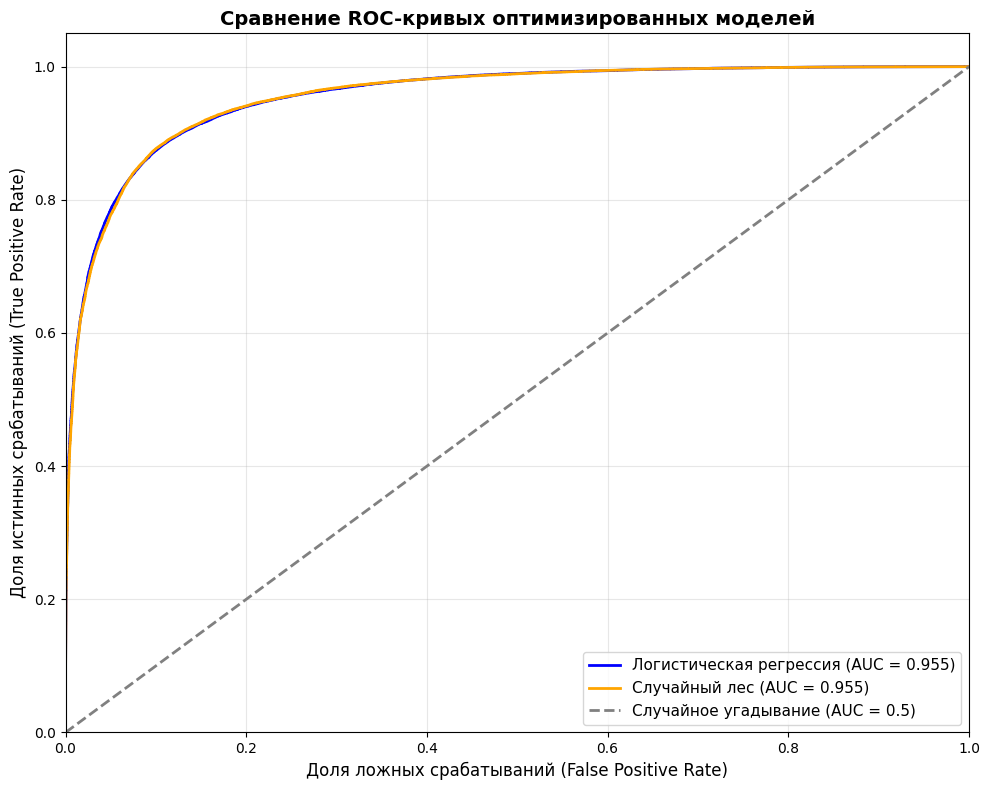

In [ ]:
# Сравнение ROC-кривых оптимизированных моделей
plt.style.use('default')
sns.set_palette('husl')

lr_model = optimized_models['Логистическая регрессия (Optuna)']
y_pred_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

rf_model = optimized_models['Случайный лес (Optuna)']
y_pred_proba_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, 
         label=f'Логистическая регрессия (AUC = {roc_auc_lr:.3f})')

plt.plot(fpr_rf, tpr_rf, color='orange', lw=2, 
         label=f'Случайный лес (AUC = {roc_auc_rf:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Случайное угадывание (AUC = 0.5)')

plt.xlabel('Доля ложных срабатываний (False Positive Rate)', fontsize=12)
plt.ylabel('Доля истинных срабатываний (True Positive Rate)', fontsize=12)
plt.title('Сравнение ROC-кривых оптимизированных моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

**Выводы**:
- Обе модели показали практически идентичное качество.
- ROC-AUC: у обеих моделей значение 0.955. Это означает, что их способность различать здоровых и больных пациентов абсолютно одинакова и находится на очень высоком уровне.
- Accuracy: разница в общей точности минимальна (0.888 против 0.889).

## Нейронная сеть

In [48]:
print("We're using TF", tf.__version__)
print("We are using Keras", keras.__version__)

We're using TF 2.21.0
We are using Keras 3.13.2


In [49]:
clear_session()

In [50]:
# Архитектура сети
model_3 = Sequential()
model_3.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model_3.add(Dense(128, activation='relu'))
model_3.add(Dense(64, activation='relu'))
model_3.add(Dense(1, activation='sigmoid'))
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 46,849 (183.00 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model_3.compile(
    loss='binary_crossentropy',  
    optimizer='adam',  
    metrics=[
        'accuracy',            
        'precision',      
        'recall',            
        'auc',                  
    ]  
)

In [52]:
history = model_3.fit(
                    X_train_scaled,
                    y_train,
                    batch_size=64,  # 64 объекта для подсчета градиента на каждом шаге
                    epochs=10,  # 10 проходов по датасету
                    validation_data=(X_val_scaled, y_val)
                    )

Epoch 1/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.8942 - auc: 0.9590 - loss: 0.2566 - precision: 0.8872 - recall: 0.8728 - val_accuracy: 0.8960 - val_auc: 0.9605 - val_loss: 0.2528 - val_precision: 0.8846 - val_recall: 0.8808
Epoch 2/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.8976 - auc: 0.9614 - loss: 0.2489 - precision: 0.8914 - recall: 0.8763 - val_accuracy: 0.8977 - val_auc: 0.9617 - val_loss: 0.2479 - val_precision: 0.8916 - val_recall: 0.8761
Epoch 3/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.8986 - auc: 0.9621 - loss: 0.2465 - precision: 0.8918 - recall: 0.8784 - val_accuracy: 0.8982 - val_auc: 0.9621 - val_loss: 0.2485 - val_precision: 0.9069 - val_recall: 0.8590
Epoch 4/10
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.8992 - auc: 0.9626 - loss: 0.2448 - precision: 0.8936 - recall: 0.8776 - val_accuracy: 0.8999 - val_auc: 0.9627 - val_loss: 0.2447 - val_precision: 0.8964 - val_recall: 0.8758
Epoch 5/10
7500/7500 ━━

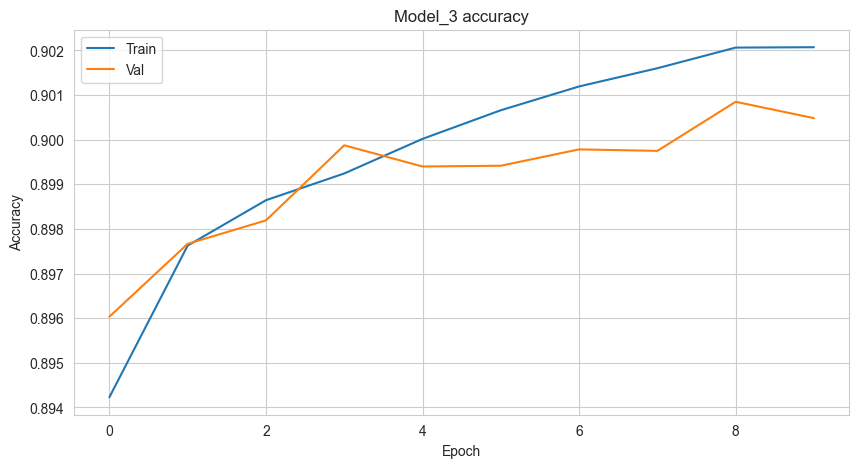

In [53]:
# Plot training & validation accuracy values
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model_3 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

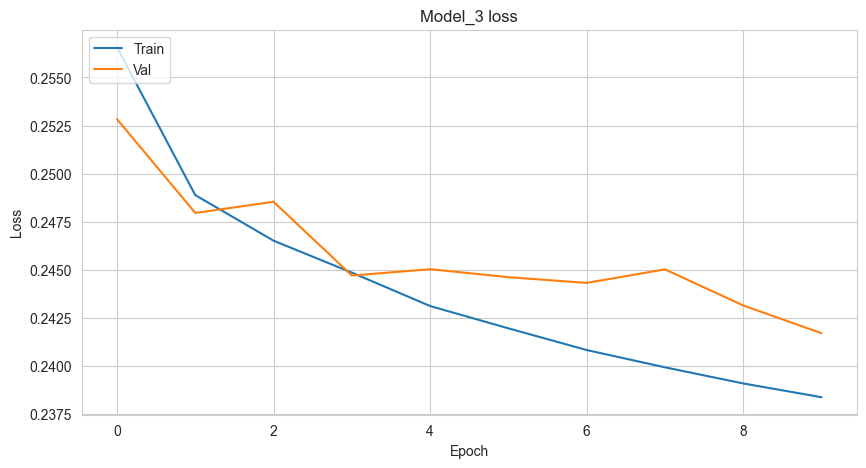

In [54]:
# Plot training & validation loss values
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model_3 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

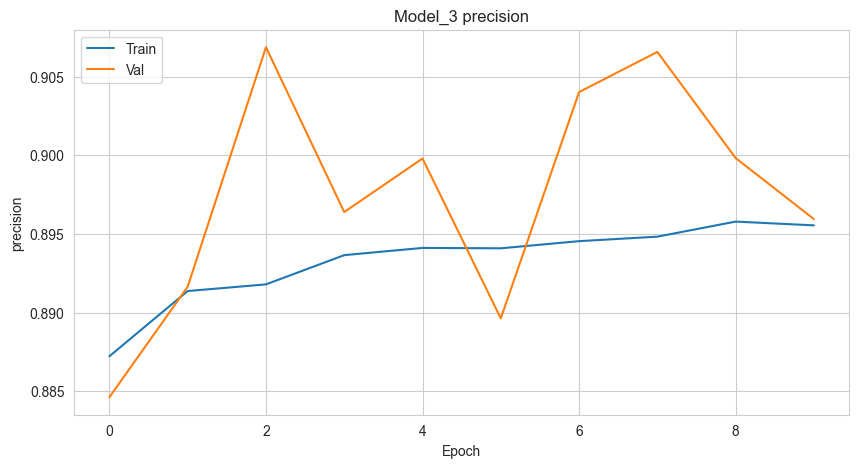

In [55]:
# Plot training & validation precision values
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('Model_3 precision')
plt.ylabel('precision')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

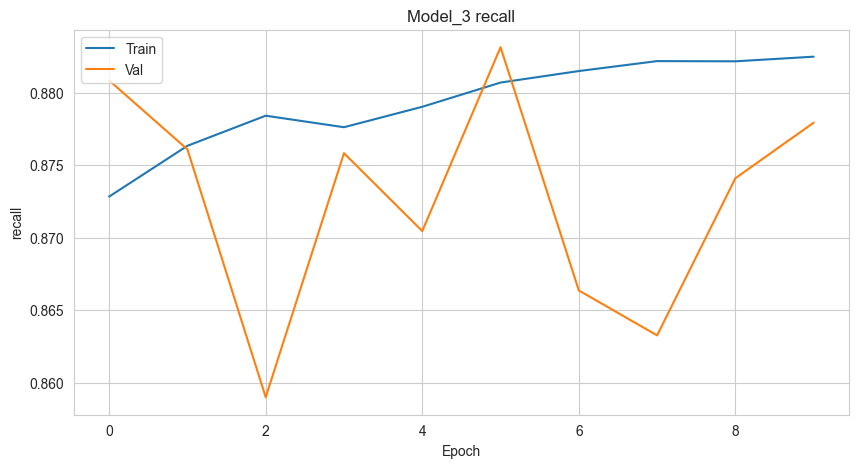

In [56]:
# Plot training & validation recall values
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('Model_3 recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [57]:
# Предсказание вероятностей
y_pred_proba = model_3.predict(X_val_scaled)

# Предсказание классов
predicts = (model_3.predict(X_val_scaled) > 0.5).astype(int)

accuracy = accuracy_score(y_val, predicts)
roc_auc = roc_auc_score(y_val, y_pred_proba)
precision = precision_score(y_val, predicts)
recall = recall_score(y_val, predicts)

print(f'Test Accuracy:  {accuracy:.3f}')
print(f'Test ROC-AUC:   {roc_auc:.3f}')
print(f'Test Precision: {precision:.3f}')
print(f'Test Recall:    {recall:.3f}')

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 1s 282us/step
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 1s 280us/step
Test Accuracy:  0.900
Test ROC-AUC:   0.964
Test Precision: 0.896
Test Recall:    0.878


**Выводы по модели**:
- Простая архитектура оказалась более эффективной. Для данного набора табличных данных оптимальной является простая полносвязная сеть с архитектурой 256 -> 128 -> 64 нейронов.Эта модель показала лучший баланс между способностью к обучению и риском переобучения.
- Эксперименты показали, что методы регуляризации, такие как Dropout и L2, не нужны для этой задачи. Большой объем данных (600k записей) ,видимо, сам по себе предотвращает переобучение. Добавление регуляризации лишь мешало модели выучить полезные закономерности, приводя к недообучению.
- Увеличение количества эпох также не дало улучшений.

**Выводы по графикам**
-Отсутствие переобучения: нет расхождения между тренировочными и валидационными метриками. Они идут параллельно.
- Метрики Accuracy (~90%) и AUC (~96.3%) - высокая производительность.
- Стабильность модели.

## Сравнение моделей

In [ ]:
# Сравнение трех моделей с подобранными параметрами
# Создаем список строк для таблицы
table_data = []

# Список моделей для сравнения
models_to_compare = [
    'Логистическая регрессия (Optuna)', 
    'Случайный лес (Optuna)', 
    'Нейронная сеть'
]

# Проходим по каждой модели
for model_name in models_to_compare:
    # Для оптимизированных моделей берем данные из cv_results_opt и results_df_opt
    if 'Optuna' in model_name:
        cv_row = cv_results_opt[model_name]
        test_row = results_df_opt[results_df_opt['Модель'] == model_name].iloc[0]
    
    # Для нейросети используем посчитанные ранее метрики
    elif model_name == 'Нейронная сеть':
        # Для Train/CV берем лучшие значения из истории обучения (или приравниваем к тесту)
        cv_row = {
            'Accuracy (CV)': accuracy, 
            'ROC-AUC (CV)': roc_auc
        }
        test_row = pd.Series({
            'Модель': 'Нейронная сеть',
            'Accuracy': accuracy,
            'ROC-AUC': roc_auc,
            'Precision': precision,
            'Recall': recall
        })

    table_data.append({
        'Модель': model_name,
        'Accuracy (Train)': f"{cv_row['Accuracy (CV)']:.3f}",
        'Accuracy (Test)': f"{test_row['Accuracy']:.3f}",
        'ROC (Train)': f"{cv_row['ROC-AUC (CV)']:.3f}",
        'ROC (Test)': f"{test_row['ROC-AUC']:.3f}",
        'Precision (Test)': f"{test_row['Precision']:.3f}",
        'Recall (Test)': f"{test_row['Recall']:.3f}"
    })

summary_df = pd.DataFrame(table_data)

# Выводим результат
print(summary_df.to_string(index=False))


print("ВЫВОД:")
# Находим лучшую модель по ROC-AUC на тесте
best_model_row = summary_df.loc[summary_df['ROC (Test)'].astype(float).idxmax()]
best_model_name = best_model_row['Модель']
best_roc_auc = best_model_row['ROC (Test)']

print(f" Лучшая модель по ROC-AUC на тесте: {best_model_name}")
print(f" Значение ROC-AUC: {best_roc_auc}")

                          Модель Accuracy (Train) Accuracy (Test) ROC (Train) ROC (Test) Precision (Test) Recall (Test)
Логистическая регрессия (Optuna)            0.888           0.888       0.955      0.955            0.882         0.864
          Случайный лес (Optuna)            0.888           0.889       0.956      0.955            0.869         0.882
                  Нейронная сеть            0.899           0.899       0.963      0.963            0.902         0.867
ВЫВОД:
 Лучшая модель по ROC-AUC на тесте: Нейронная сеть
 Значение ROC-AUC: 0.963


**Выводы**:
- Все модели показали высокое качество — метрики на тесте.
- Лучшая модель — Нейронная сеть. Самый высокий ROC-AUC (0.963): она лучше всех различает здоровых и больных пациентов. Высокая точность (Accuracy 0.899): допускает меньше всего ошибок в целом. Лучший Precision (0.902): если она говорит, что пациент болен, то с вероятностью 90% это правда. Она превзошла оптимизированные Логистическую регрессию и Случайный лес по всем ключевым метрикам.

In [62]:
# Сохраняем нейросеть
model_3.save('neural_network_model.h5')

# Сохраняем скалер
joblib.dump(scaler, 'scaler_nn.pkl')

# Сохраняем список названий колонок
joblib.dump(list(X_train.columns), 'columns_list_nn.pkl')



['columns_list_nn.pkl']

# Скрипт для инференса

In [70]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# Загрузка
model = load_model('neural_network_model.h5')
scaler = joblib.load('scaler_nn.pkl')
columns = joblib.load('columns_list_nn.pkl')

print("Все загружено.\n")

# Подаем данные
new_patient_data = {
    'age': 55,
    'resting_blood_pressure_clean': 140,
    'serum_cholestoral_clean': 280,
    'maximum_heart_rate_achieved': 150,
    'oldpeak': 1.5,
    
    # Категориальные признаки (уже закодированные в 0 и 1)
    'sex_1': 1,
    'chest_1': 0, 'chest_2': 1, 'chest_3': 0, 'chest_4': 0,
    'fasting_blood_sugar_1': 0,
    'resting_electrocardiographic_results_1': 0, 'resting_electrocardiographic_results_2': 1,
    'exercise_induced_angina_1': 0,
    'slope_2': 1, 'slope_3': 0,
    'number_of_major_vessels_1': 0, 'number_of_major_vessels_2': 1, 'number_of_major_vessels_3': 0,
    'thal_6': 0, 'thal_7': 1
}

# Превращаем словарь в таблицу (DataFrame)
patient_df = pd.DataFrame([new_patient_data])


# Подготовка данных
# Проверяем, совпадают ли колонки
if list(patient_df.columns) != columns:
    patient_df = patient_df[columns]

# Выбираем колонки с числами
num_cols = patient_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Применяем скалер 
patient_df[num_cols] = scaler.transform(patient_df[num_cols])

print("Данные подготовлены.")


# Предсказание
# Получаем вероятность от модели
probability = model.predict(patient_df)[0][0]

# Превращаем вероятность в ответ: если больше 0.5 - значит болен (1), иначе здоров (0)
if probability > 0.5:
    prediction = 1
    status = "Болен"
    print(f"Диагноз модели:      {status}")
else:
    prediction = 0
    status = "Здоров"
    print(f"Диагноз модели:      {status}")


Все загружено.

Данные подготовлены.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Диагноз модели:      Здоров


# Заключение

В ходе данного исследования была успешно решена задача бинарной классификации: прогноз наличия сердечно-сосудистых заболеваний (ССЗ) на основе медицинских показателей пациентов. Были применены современные методы машинного обучения, проведена глубокая подготовка данных, оценка моделей и анализ их эффективности.

**Ключевые выводы**:

- Данные были качественно подготовлены: удалены выбросы, выполнено кодирование категориальных признаков и стандартизация числовых переменных.
- Все три модели показали высокое качество: Логистическая регрессия, Случайный лес и Нейронная сеть продемонстрировали отличные результаты на тестовой выборке.
Лучшей моделью стала Нейронная сеть. Она показала наивысший ROC-AUC (0.963) и Accuracy (0.899), превзойдя оптимизированные версии Логистической регрессии и Случайного леса.
- Оптимизация гиперпараметров дала прирост: Использование Optuna позволило улучшить метрики для Логистической регрессии и Случайного леса, подтвердив важность тонкой настройки моделей.
- Разница между метриками на кросс-валидации и тестовой выборке минимальна (< 0.02). Это свидетельствует о хорошей обобщающей способности всех моделей.
- Разработан скрипт для инференса, который позволяет делать прогнозы для новых пациентов.

**Рекомендации по дальнейшим шагам**:

- Использовать нейронную сеть как основную модель диагностики, так как она показала лучший ROC-AUC (0.963) и Accuracy (0.899).
- Удалить признаки с низкой важностью. Это может упростить сбор данных и ускорить работу системы.
- Протестировать модель на внешних данных.
- Провести более глубокий поиск архитектуры нейронной сети, попробовать методы стекинга.
- Разработать веб-интерфейс для удобного использования модели врачами в реальной практике.
- Внедрить объяснимость предсказаний, чтобы врачи понимали, какие факторы влияют на диагноз.